In [1]:
import numpy as np
import scipy.linalg as LA
from numpy.fft import fft, ifft
import matplotlib
from numba import njit, prange
import matplotlib.pyplot as plt
from helpers_takarada import * 
import seaborn as sns
def colorFader(c1, c2, mix=0.5):
    c1 = np.array(matplotlib.colors.to_rgb(c1))
    c2 = np.array(matplotlib.colors.to_rgb(c2))
    return matplotlib.colors.to_hex((1-mix)*c1 + mix*c2)
from module_takarada import * 
parameters1 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-5,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-5,
'dmu' : 5.,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

parameters2 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-5,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-5,
'dmu' : 5.,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

Nk = 1000


(4.3903118308437415e-11+0j)

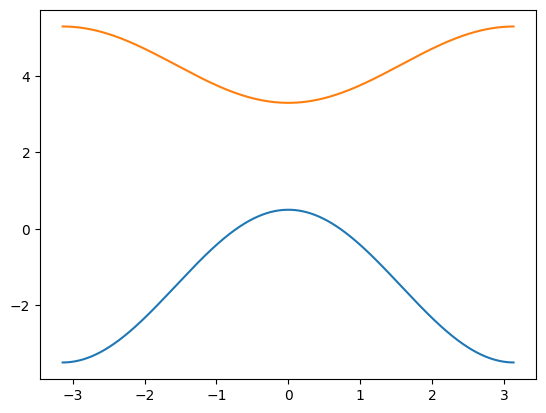

In [5]:

a = 1.
b = 0.2#5
t = 1.
t_ = 0.5
t12 = 0.
Vc = 0.
delta = 0.

#epsilon = 0.5
#epsilon_ = epsilon
#Vb = 3.
Vc = 0.3
delta = 0.

epsilon = 1.
epsilon_ = epsilon
Vb = 3
gap = 0.0

epsilon = 0.5*(gap + 2*t_ + 2*t)

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]

mu0 = 0.
include_hartree = True
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()

plt.plot(m.K, m.energije[0])
plt.plot(m.K, m.energije[1])
gap, m.delta_b

np.sum(m.rho[1,1,:]) / Nk

In [6]:
parameters1 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-8,
'N_epsilon' : 5,
'maxiter' : 1000,
'eps_last' : 1e-8,
'dmu' : 5.,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

parameters2 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-8,
'N_epsilon' : 5,
'maxiter' : 1000,
'eps_last' : 1e-8,
'dmu' : 5.,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

Nk = 500


a = 1.
b = 0.#5
t = 1.
t_ = 0.5
t12 = 0.
Vc = 0.
delta = 0.

#epsilon = 0.5
#epsilon_ = epsilon
#Vb = 3.
gaps = np.linspace(-3,1,21)
epsilons = 0.5*(gaps + 2*t_ + 2*t)
Vbs = np.linspace(0,1.5,21)
include_hartree = True

order_parameters = np.zeros((len(Vbs), len(epsilons)))
ns2 = np.copy(order_parameters)

for i, Vb in enumerate(Vbs):
    for j, epsilon in enumerate(epsilons):
        print(i,j)
        epsilon_ = epsilon


        phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]

        mu0 = 0.
        m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
        m.GS()

        order_parameters[i,j] = m.delta_b.real
        ns2[i,j] = np.sum(m.rho[1,1,:]).real

0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
1 18
1 19
1 20
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
2 10
2 11
2 12
2 13
2 14
2 15
2 16
2 17
2 18
2 19
2 20
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
3 15
3 16
3 17
3 18
3 19
3 20
4 0
4 1
4 2
4 3
4 4
4 5
4 6
4 7
4 8
4 9
4 10
4 11
4 12
4 13
4 14
4 15
4 16
4 17
4 18
4 19
4 20
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
5 10
5 11
5 12
5 13
5 14
5 15
5 16
5 17
5 18
5 19
5 20
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
6 9
6 10
6 11
6 12
6 13
6 14
6 15
6 16
6 17
6 18
6 19
6 20
7 0
7 1
7 2
7 3
7 4
7 5
7 6
7 7
7 8
7 9
7 10
7 11
7 12
7 13
7 14
7 15
7 16
7 17
7 18
7 19
7 20
8 0
8 1
8 2
8 3
8 4
8 5
8 6
8 7
8 8
8 9
8 10
8 11
8 12
8 13
8 14
8 15
8 16
8 17
8 18
8 19
8 20
9 0
9 1
9 2
9 3
9 4
9 5
9 6
9 7
9 8
9 9
9 10
9 11
9 12
9 13
9 14
9 15
9 16
9 17
9 18
9 19
9 20
10 0
10 1
10 2
10 3
10 4
10 5
10 6
10 7
10 8
10 9


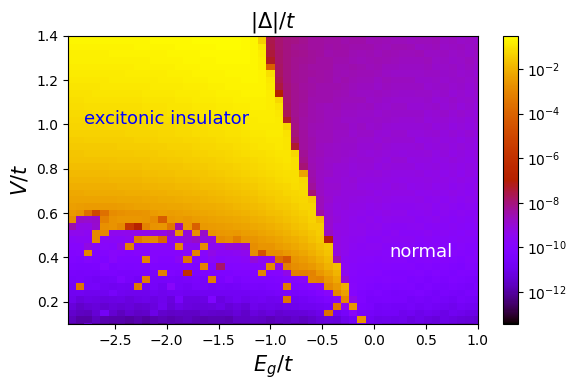

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
cm = plt.pcolormesh(gaps, Vbs, np.abs(order_parameters), norm=matplotlib.colors.LogNorm(), cmap='gnuplot')
plt.colorbar(cm)
plt.ylim(0.1,1.4)
plt.xlim(-2.95,1)
plt.xlabel(r'$E_g/t$', fontsize=15)
plt.ylabel(r'$V/t$', fontsize=15)
plt.text(-2.8,1, 'excitonic insulator', fontsize=13, color='blue')
plt.text(0.15,0.4,'normal', fontsize=13, color='white')
plt.title(r'$|\Delta|/t$', fontsize=15)
plt.tight_layout()
plt.savefig('diagram_my3.png')

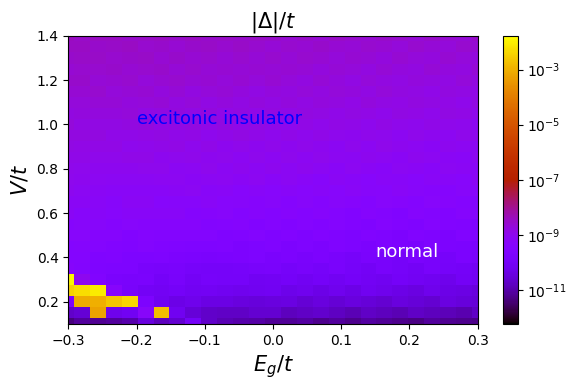

In [61]:
fig, ax = plt.subplots(figsize=(6,4))
cm = plt.pcolormesh(gaps, Vbs, np.abs(order_parameters), norm=matplotlib.colors.LogNorm(), cmap='gnuplot')
plt.colorbar(cm)
plt.ylim(0.1,1.4)
plt.xlim(-0.3,0.3)
plt.xlabel(r'$E_g/t$', fontsize=15)
plt.ylabel(r'$V/t$', fontsize=15)
plt.text(-0.2,1, 'excitonic insulator', fontsize=13, color='blue')
plt.text(0.15,0.4,'normal', fontsize=13, color='white')
plt.title(r'$|\Delta|/t$', fontsize=15)
plt.tight_layout()
#plt.savefig('diagram_my3.png')

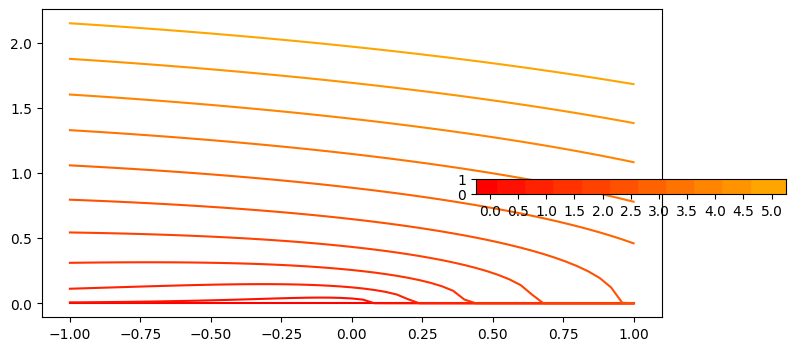

In [6]:
c1, c2 = 'red', 'orange'
fig, ax = plt.subplots(figsize=(8,4))
ins = ax.inset_axes([0.7,0.4,0.5,0.05])
gaps = epsilons - 2*t_ - (-epsilons + 2*t)
for i, Vb in enumerate(Vbs):
    plt.plot(gaps, np.abs(order_parameters[i]), color=colorFader(c1, c2, i/(len(Vbs) - 1)))
    ins.axvline(i,  color=colorFader(c1, c2, i/(len(Vbs) - 1)), lw=30)
ins.set_xticks(range(len(Vbs)))
ins.set_xticklabels(Vbs)
plt.show()


array([-9.90447662e-06+0.00000000e+00j, -2.95511486e-07-6.50521303e-23j])

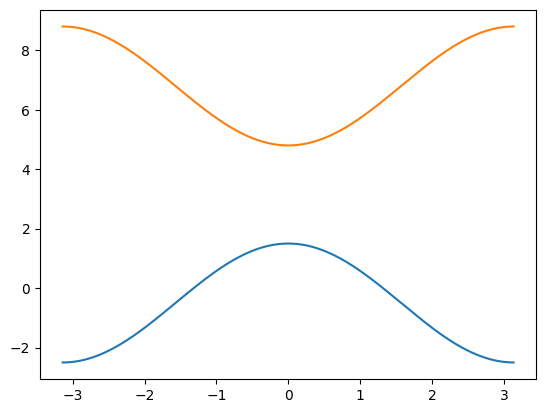

In [12]:
plt.plot(m.K, m.energije[0])
plt.plot(m.K, m.energije[1])
Delta(m.K, m.rho, Vb, Vc)

In [456]:
omegas = np.linspace(-1,1,501)
Gamma = 0.03
 
T = 1/50

spektralka = Spektralka(omegas, m.mu, m.energije, Gamma)

tok = j_tok(m.K, m.phys_parameters, m.mu)
tok_tilde = np.einsum('jix, jlx,lmx -> imx', m.vecs.conj(), tok, m.vecs)

m1 = mf_matrix1(m.K, m.rho, m.phys_parameters, m.mu)
m1_tilde = np.einsum('jix, jlx,lmx -> imx', m.vecs.conj(), m1, m.vecs)

m2 = mf_matrix2(m.K, m.rho, m.phys_parameters, m.mu)
m2_tilde = np.einsum('jix, jlx,lmx -> imx', m.vecs.conj(), m2, m.vecs)

m3 = mf_matrix3(m.K, m.rho, m.phys_parameters, m.mu)
m3_tilde = np.einsum('jix, jlx,lmx -> imx', m.vecs.conj(), m3, m.vecs)

m4 = mf_matrix4(m.K, m.rho, m.phys_parameters, m.mu)
m4_tilde = np.einsum('jix, jlx,lmx -> imx', m.vecs.conj(), m4, m.vecs)

rhos, thetas = rho_operators(m.K, phys_parameters)
thetas = np.diag(thetas)
rhos_tilde = np.zeros(rhos.shape, dtype=np.complex128)
for i in range(rhos_tilde.shape[0]):
    rhos_tilde[i] = np.einsum('jix, jlx,lmx -> imx', m.vecs.conj(), rhos[i], m.vecs)


phi = phi_Kubo(m.K, tok_tilde, tok_tilde, spektralka, omegas).real
chi_j_j0 = np.sum(phi * (-fd_1(omegas, T))) * (omegas[1] - omegas[0])
chi_j_j1 = np.sum(phi * omegas * (-fd_1(omegas, T))) * (omegas[1] - omegas[0])

chis_rho_j0 = np.zeros(rhos_tilde.shape[0])
chis_rho_j1 = np.zeros(rhos_tilde.shape[0])

for i in range(rhos_tilde.shape[0]):
    phi = phi_Kubo(m.K, rhos_tilde[i], tok_tilde, spektralka, omegas).real
    chis_rho_j0[i] = np.sum(phi * (-fd_1(omegas, T))) * (omegas[1] - omegas[0])
    chis_rho_j1[i] = np.sum(omegas * phi * (-fd_1(omegas, T))) * (omegas[1] - omegas[0])

chis_rho_rho0 = np.zeros((rhos_tilde.shape[0], rhos_tilde.shape[0]))
for i in range(rhos_tilde.shape[0]):
    for j in range(rhos_tilde.shape[0]):
        phi = phi_Kubo(m.K, rhos_tilde[i], rhos_tilde[j], spektralka, omegas).real
        chis_rho_rho0[i,j] = np.sum(phi * (-fd_1(omegas, T))) * (omegas[1] - omegas[0])


chi_j_j_delta0 = chis_rho_j0 @ thetas @ LA.inv(np.eye(4) - chis_rho_rho0 @ thetas) @ chis_rho_j0
chi_j_j_delta1 = chis_rho_j1 @ thetas @ LA.inv(np.eye(4) - chis_rho_rho0 @ thetas) @ chis_rho_j1



T = 0.1
fs = np.zeros(m.energije.shape)
fs = 1/(np.exp((m.energije - m.mu)/T) + 1) 

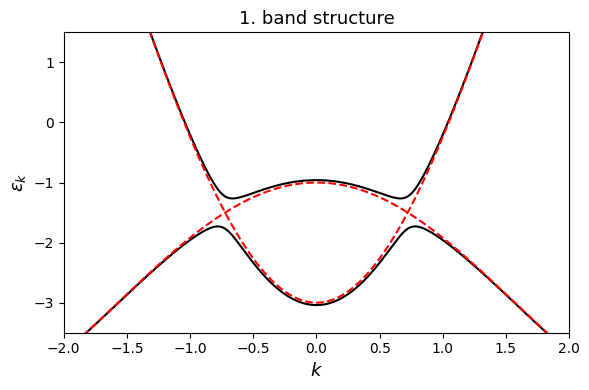

In [615]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(m.K, m.energije[0], color='black')
plt.plot(m.K, m.energije[1], color='black')
b, t, t_, t12, epsilon, Vb, Vc, delta = phys_parameters
plt.plot(m.K, 2*t*np.cos(m.K) - epsilon, color='red', ls='dashed')
plt.plot(m.K, -2*t_*np.cos(m.K) + epsilon, color='red', ls='dashed')

plt.ylim(-3.5,1.5)

plt.xlim(-2,2)
plt.xlabel(r'$k$', fontsize=13)
plt.ylabel(r'$\epsilon_k$', fontsize=13)
gap = np.min(m.energije[1]) - np.max(m.energije[0])
plt.title(r'1. band structure', fontsize=13)
plt.tight_layout()
plt.savefig('slika1_tak.png')

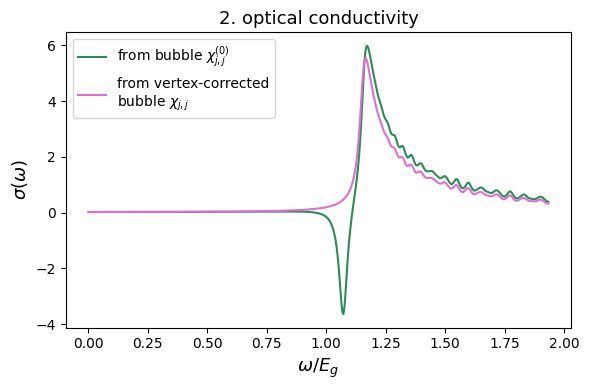

In [616]:
omegas = np.linspace(0.001,0.9,501)
Gamma = 0.005
chi_j_j = phi_Kubo_omegas(m.K, tok_tilde, tok_tilde, omegas, m.energije, fs, Gamma)
chi_rho_rho = np.zeros((rhos_tilde.shape[0], rhos_tilde.shape[0], len(omegas)), dtype=np.complex128)
chi_rho_j = np.zeros((rhos_tilde.shape[0], len(omegas)), dtype=np.complex128)
chi_j_rho = chi_rho_j.reshape((1, rhos_tilde.shape[0], len(omegas)))
for i in range(rhos_tilde.shape[0]):
    chi_rho_j[i] = phi_Kubo_omegas(m.K, rhos_tilde[i], tok_tilde, omegas, m.energije, fs, Gamma)
    for j in range(rhos_tilde.shape[0]):
        chi_rho_rho[i,j] = phi_Kubo_omegas(m.K, rhos_tilde[i], rhos_tilde[j], omegas, m.energije, fs, Gamma)

identity = np.zeros((4, 4, len(omegas)))
identity[0,0,:] = 1.
identity[1,1,:] = 1.
inverz = np.zeros((4, 4, len(omegas)), dtype=np.complex128)
for i in range(len(omegas)):
    inverz[:,:,i] = LA.inv(np.eye(4) - chi_rho_rho[:,:,i] @ thetas)

dchi_j_j = np.einsum('ijo, jl, lmo, mo -> io', chi_j_rho, thetas, inverz, chi_rho_j)


fig, ax = plt.subplots(figsize=(6,4))
ax.set_xlabel(r'$\omega/E_g$', fontsize=13)
plt.plot(omegas/gap, -(chi_j_j + dchi_j_j[0]).imag / omegas / np.pi, label=r'from bubble $\chi_{j,j}^{(0)}$', color='seagreen')
plt.plot(omegas/gap, -chi_j_j.imag / omegas / np.pi, label=r'from vertex-corrected' + '\n' + r'bubble $\chi_{j,j}$', color='orchid')
plt.ylabel(r'$\sigma(\omega)$', fontsize=13)
plt.title(r'2. optical conductivity', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('slika2_tak.png')
plt.show()


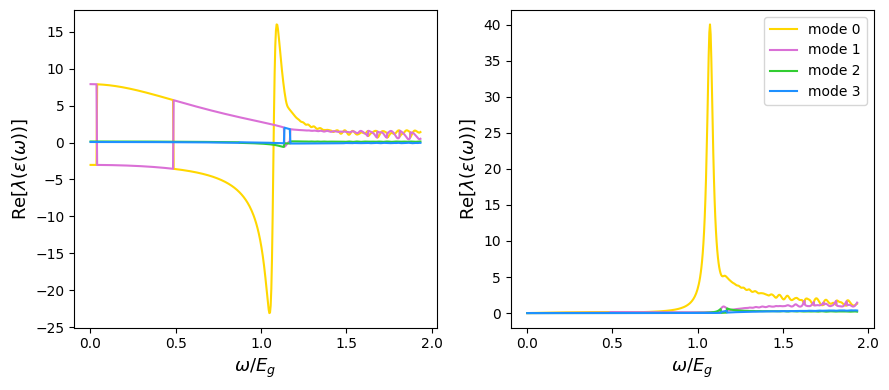

In [614]:

chi_rho_rho_full = np.einsum('ijo, jlo -> ilo', inverz, chi_rho_rho)
epsilon = identity - np.einsum('ij, jlo -> ilo', thetas, chi_rho_rho_full)
Vals = np.zeros((4, len(omegas)), dtype=np.complex128)
for i in range(len(omegas)):
    vals = LA.eigvals(epsilon[:,:,i])
    Vals[:,i] = vals

Vals_sorted = np.zeros_like(Vals)
for i in range(len(omegas)):
    vals = LA.eigvals(epsilon[:,:,i])
    idx = np.argsort(vals.real)
    Vals_sorted[:, i] = vals[idx]

fig, ax = plt.subplots(ncols=2, figsize=(9,4))
cols = ['gold', 'orchid', 'limegreen', 'dodgerblue']
for n in range(4):
    ax[0].plot(omegas / gap, Vals[n].real, label=f"mode {n}", color=cols[n])
    ax[1].plot(omegas / gap, -Vals[n].imag, label=f"mode {n}", color=cols[n])
for j in range(2):
    ax[j].set_xlabel(r'$\omega / E_g$', fontsize=13)
ax[0].set_ylabel(r'$\text{Re}[ \lambda(\varepsilon(\omega)) ]$', fontsize=13)
ax[1].set_ylabel(r'$\text{Re}[ \lambda(\varepsilon(\omega)) ]$', fontsize=13)

u = np.ones(4)
u /= np.linalg.norm(u)

loss = np.zeros(len(omegas))
for i in range(len(omegas)):
    eps_inv = np.linalg.inv(epsilon[:,:,i])
    loss[i] = -np.imag(u.conj() @ eps_inv @ u)
omega0 = omegas[np.argmax(np.abs(np.gradient(Vals[0].real)))]


plt.tight_layout()
plt.legend()
plt.show()



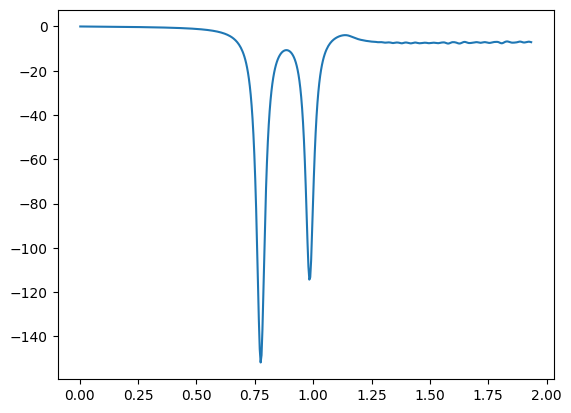

In [573]:
loss = np.zeros(len(omegas))
for i in range(len(omegas)):
    eps_inv = np.linalg.inv(epsilon[:,:,i])
    loss[i] = -np.imag(np.trace(eps_inv))

plt.plot(omegas/gap, loss)

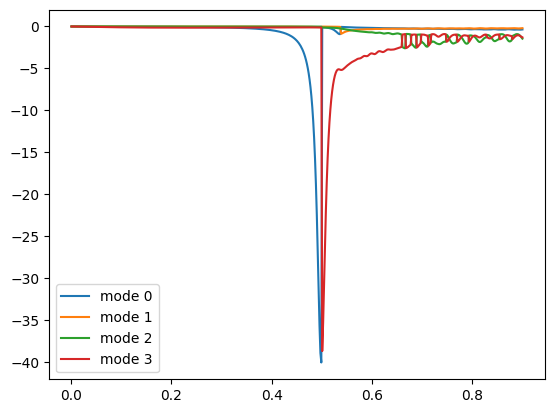

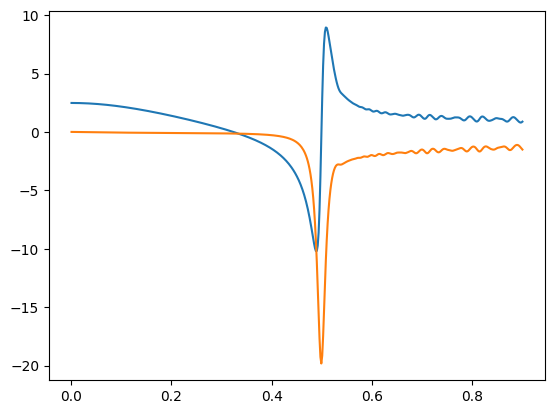

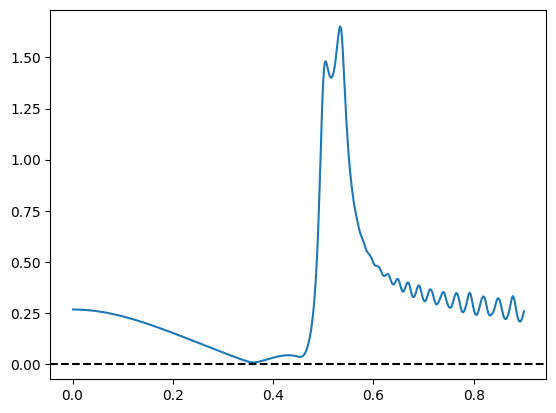

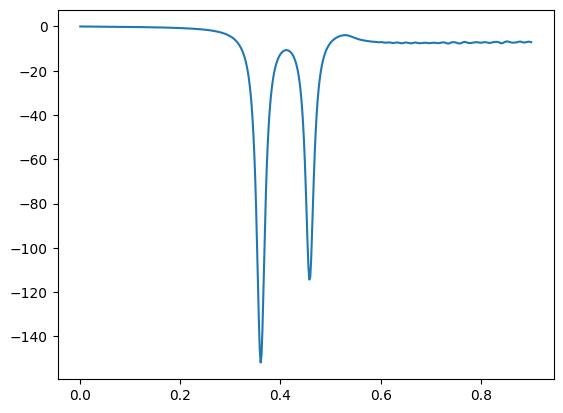

In [571]:

for n in range(4):
    plt.plot(omegas, Vals_sorted[n].imag, label=f"mode {n}")
plt.legend()

plt.show()
u = np.ones(4)
u = u / np.linalg.norm(u)

eps_phys = np.zeros(len(omegas), dtype=complex)
for i in range(len(omegas)):
    eps_phys[i] = u.conj() @ epsilon[:,:,i] @ u

plt.plot(omegas, eps_phys.real)
plt.plot(omegas, eps_phys.imag)

plt.show()

det_eps = np.array([np.linalg.det(epsilon[:,:,i]) for i in range(len(omegas))])
plt.plot(omegas, np.abs(det_eps))
plt.axhline(0, color='k', linestyle='--')
plt.show()

loss = np.zeros(len(omegas))
for i in range(len(omegas)):
    eps_inv = np.linalg.inv(epsilon[:,:,i])
    loss[i] = -np.imag(np.trace(eps_inv))

plt.plot(omegas, loss)

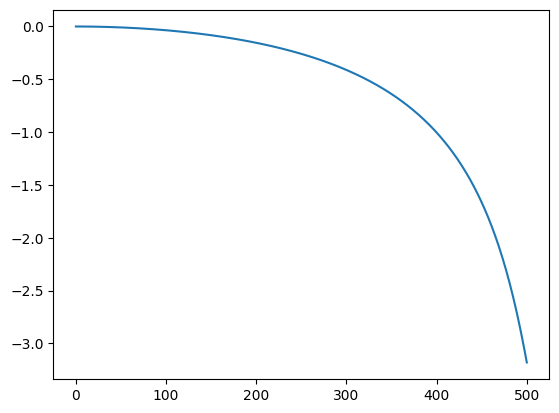

In [333]:
omegas = np.linspace(0.001,0.5,501)
Gamma = 0.01
phiomega = phi_Kubo_omegas(m.K, tok_tilde, tok_tilde, omegas, m.energije, fs, Gamma)

phi0 = phi_Kubo_omegas(m.K, tok_tilde, tok_tilde,
                       np.array([0.0]), m.energije, fs, Gamma)[0]

phiomega_corr = phiomega - phi0

plt.plot(phiomega_corr)

c:\Users\anast\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\anast\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


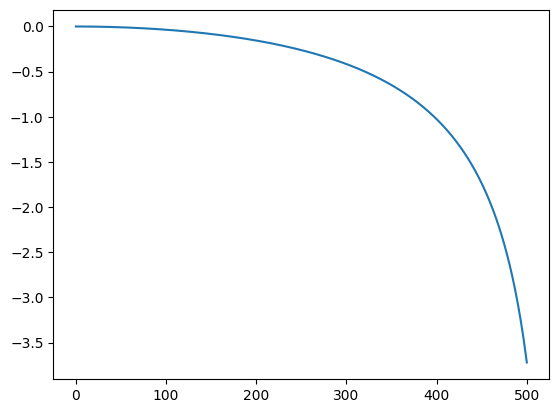

In [329]:
phi0 = phi_Kubo_omegas(m.K, tok_tilde, tok_tilde,
                       np.array([0.0]), m.energije, fs, Gamma)[0]

phiomega_corr = phiomega - phi0

plt.plot(phiomega_corr)